In [1]:
#required packages
import pandas as pd 
import math 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [2]:
#initalising dataframe 

data = pd.read_csv('Tabular_DS_Jobs.csv')
df = pd.DataFrame(data)

total_rows_df = df.count()

#Data Cleaning 

keep_cols = [ # only keeping the relevant columns to perform analysis 
    "Job Title",
    "Rating",
    "Company Name",
    "Headquarters",
    "job_state",
    "avg_salary",
    "max_salary",
    "company_age",
    "Type of ownership",
    "seniority",

]


df = df[keep_cols]

df["Job Title"] = df["Job Title"].astype("string")

df["Company Name"] = df["Company Name"].astype("string")


df["job_state"] = df["job_state"].astype("string")
df["job_state"] = df["job_state"].str.strip().str.upper()
state_mask = df["job_state"].str.fullmatch(r"[A-Z]{2}")




df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df[df["Rating"].notna()]
df["Rating"] = df["Rating"].astype(float)


df["avg_salary"] = pd.to_numeric(df["avg_salary"], errors="coerce")
df = df[df["avg_salary"].notna()]
df["avg_salary"] = df["avg_salary"].astype(int)



df["company_age"] = pd.to_numeric(df["company_age"], errors="coerce")
df = df[df["company_age"].notna()]
df["company_age"] = df["company_age"].astype(int)



df["seniority"] = df["seniority"].astype("string")
df["seniority"] = df["seniority"].str.strip().str.lower()
df["seniority"] = df["seniority"].apply(
    lambda x: "YES" if isinstance(x, str) and "senior" in x
    else "NO"
)


print("\nDataframe after cleaning:")
print(df.head(5))
print(f"Total rows: {len(df)}")




Dataframe after cleaning:
           Job Title  Rating        Company Name            Headquarters  \
0  Sr Data Scientist     3.1         Healthfirst            New York, NY   
1     Data Scientist     4.2             ManTech             Herndon, VA   
2     Data Scientist     3.8      Analysis Group              Boston, MA   
3     Data Scientist     3.5             INFICON  Bad Ragaz, Switzerland   
4     Data Scientist     2.9  Affinity Solutions            New York, NY   

  job_state  avg_salary  max_salary  company_age        Type of ownership  \
0        NY         154         171           27   Nonprofit Organization   
1        VA         154         171           52         Company - Public   
2        MA         154         171           39  Private Practice / Firm   
3        MA         154         171           20         Company - Public   
4        NY         154         171           22        Company - Private   

  seniority  
0       YES  
1        NO  
2        NO

In [3]:
mean_salary = df["avg_salary"].mean()
median_salary = df["avg_salary"].median()
mode_salary = df["avg_salary"].mode().iloc[0] if not df["avg_salary"].mode().empty else None
std_salary = df["avg_salary"].std()


print(f"Mean:   {mean_salary}")
print(f"Median: {median_salary}")
print(f"Mode:   {mode_salary}")
print(f"Std:    {std_salary}")




headquarters_state = (df["Headquarters"].astype("string").str.split(",", expand=True).iloc[:, -1].str.strip().str.upper()
)

job_state_values = df["job_state"].astype("string").str.strip().str.upper()

same_state_indicator = (headquarters_state == job_state_values).fillna(False).astype(int)
df["same_state_indicator"] = same_state_indicator

same_state_salaries = df[df["same_state_indicator"] == 1]["avg_salary"]
different_state_salaries = df[df["same_state_indicator"] == 0]["avg_salary"]

n_same = len(same_state_salaries)
n_diff = len(different_state_salaries)

mean_same = same_state_salaries.mean()
mean_diff = different_state_salaries.mean()

variance_same = ((same_state_salaries - mean_same) ** 2).sum() / (n_same - 1)
variance_diff = ((different_state_salaries - mean_diff) ** 2).sum() / (n_diff - 1)

standard_error = math.sqrt((variance_same / n_same) + (variance_diff / n_diff))

t_statistic = (mean_same - mean_diff) / standard_error

numerator_df = ((variance_same / n_same) + (variance_diff / n_diff)) ** 2
denominator_df = ((variance_same / n_same) ** 2) / (n_same - 1) + ((variance_diff / n_diff) ** 2) / (n_diff - 1)
ttest_degrees_of_freedom = numerator_df / denominator_df

print("Two-Sample t-Test: Same State vs Different State")
print("Mean (Same State):", mean_same)
print("Mean (Different State):", mean_diff)
print("Variance (Same State):", variance_same)
print("Variance (Different State):", variance_diff)
print("t-statistic:", t_statistic)
print("Degrees of Freedom:", ttest_degrees_of_freedom)


Mean:   123.61212121212121
Median: 114.0
Mode:   107
Std:    39.78669802779487
Two-Sample t-Test: Same State vs Different State
Mean (Same State): 119.46649484536083
Mean (Different State): 129.52573529411765
Variance (Same State): 1055.70171688111
Variance (Different State): 2282.095276210115
t-statistic: -3.01779579596903
Degrees of Freedom: 442.6698186516329


In [4]:
valid_df = df[
    (df["Type of ownership"] != "-1") &
    (df["Type of ownership"].str.upper() != "UNKNOWN")
]


observed_table = pd.crosstab(valid_df["seniority"], valid_df["Type of ownership"])

observed = observed_table.values
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
grand_total = observed.sum()

expected = []
for r in row_totals:
    expected_row = []
    for c in col_totals:
        expected_row.append((r * c) / grand_total)
    expected.append(expected_row)

chi_square_statistic = 0
for i in range(len(observed)):
    for j in range(len(observed[0])):
        if expected[i][j] > 0:
            chi_square_statistic += (observed[i][j] - expected[i][j])**2 / expected[i][j]

degrees_of_freedom = (len(row_totals) - 1) * (len(col_totals) - 1)

print("Chi-Square Test: Seniority vs Type of Ownership")
print("Observed Frequencies:")
print(observed_table)
print("Expected Frequencies:")
print(pd.DataFrame(expected, index=observed_table.index, columns=observed_table.columns))
print("Chi-Square Statistic:", chi_square_statistic)
print("Degrees of Freedom:", degrees_of_freedom)


age_salary = df.groupby("company_age")["avg_salary"].mean().reset_index()
print(age_salary)
age_salary = age_salary.sort_values("company_age")
age_salary = age_salary[age_salary["company_age"] > 0]
age_salary.to_csv("age_salary_trend.csv", index=False)


list = df.columns.tolist()
print(df[["avg_salary", "company_age", "seniority", "same_state_indicator", "Rating"]].dtypes)
print("Columns in DataFrame:", list)


df["seniority"] = df["seniority"].map({"YES": 1, "NO": 0})

df_model = df[[
    "avg_salary",
    "company_age",
    "seniority",
    "same_state_indicator",
    "Rating"
]].dropna()

X = df_model.drop("avg_salary", axis=1)
y = df_model["avg_salary"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())



kmeans_setup = df[["company_age", "max_salary"]].dropna()


kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)


kmeans_setup["cluster"] = kmeans.labels_


centroids = kmeans.cluster_centers_
print("Cluster centroids:\n", centroids)


X = df[["avg_salary", "company_age", "Rating"]]
y = df["seniority"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)





Chi-Square Test: Seniority vs Type of Ownership
Observed Frequencies:
Type of ownership  College / University  Company - Private  Company - Public  \
seniority                                                                      
NO                                    3                344               115   
YES                                   0                 42                37   

Type of ownership  Contract  Government  Hospital  Nonprofit Organization  \
seniority                                                                   
NO                        2          10         1                      32   
YES                       0           0         0                       4   

Type of ownership  Other Organization  Private Practice / Firm  Self-employed  \
seniority                                                                       
NO                                  4                        4              2   
YES                                 1                    

/var/data/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


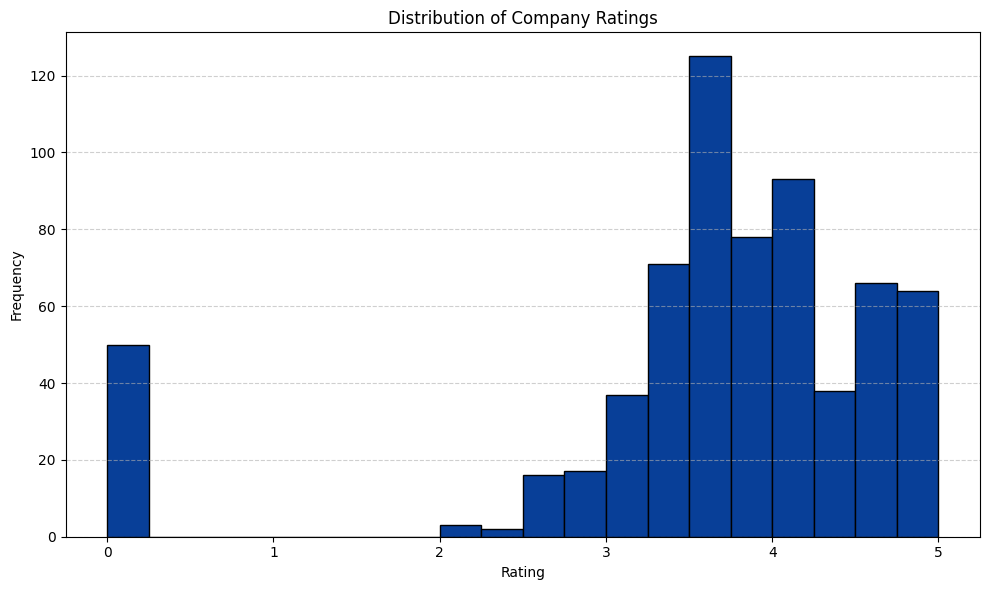

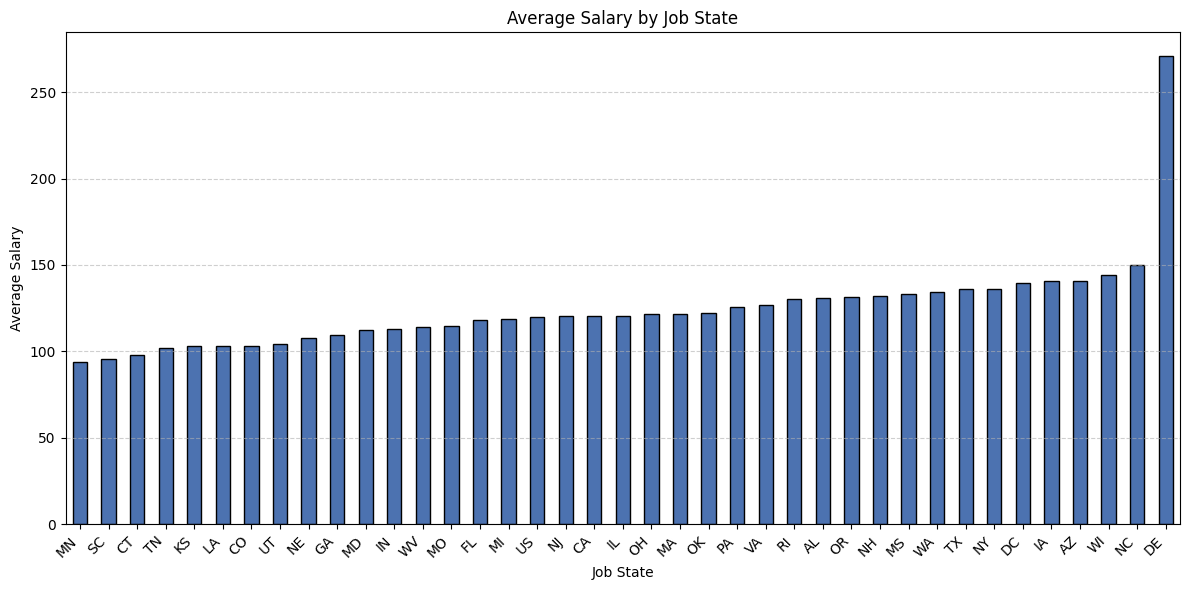

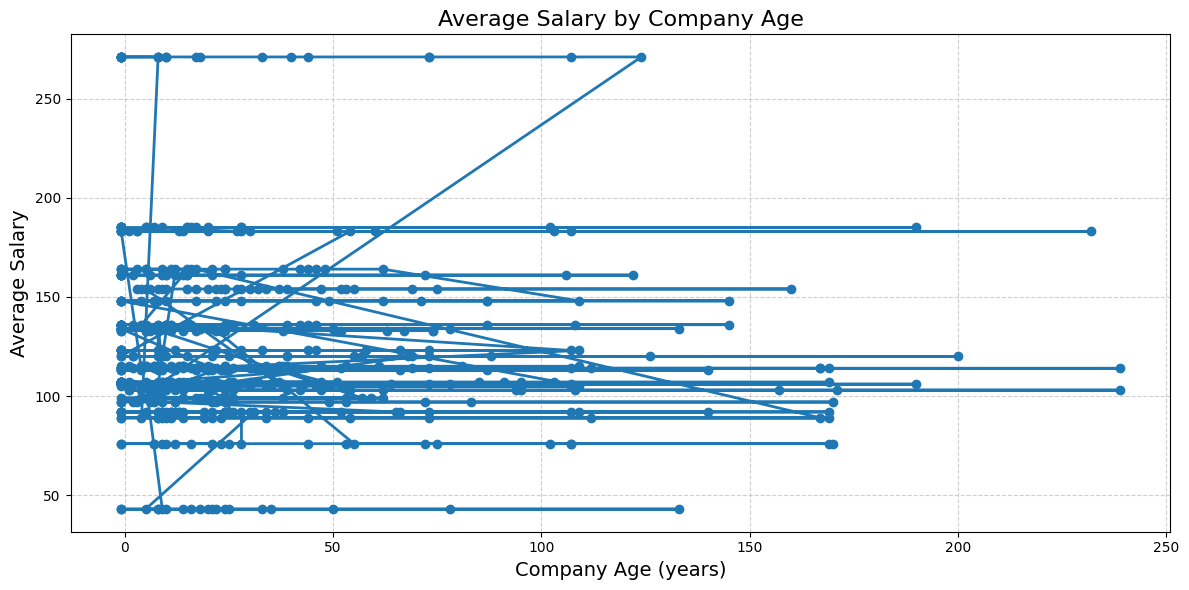

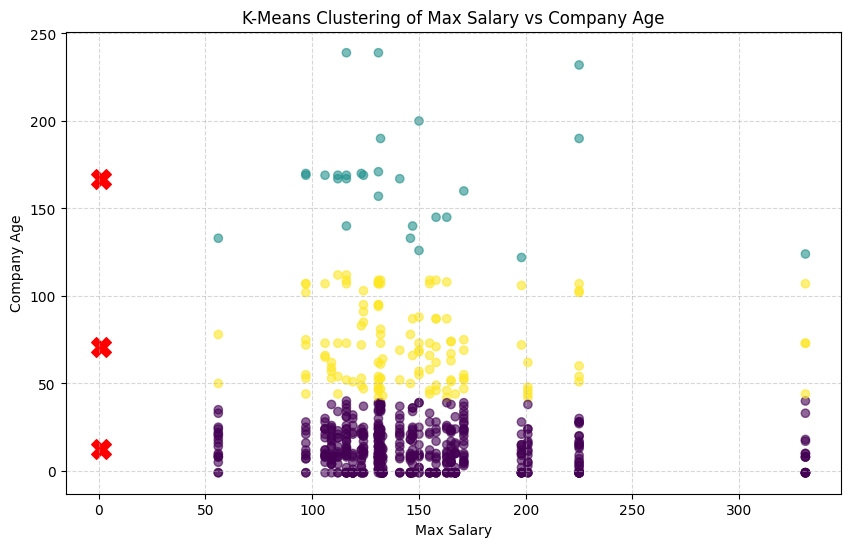

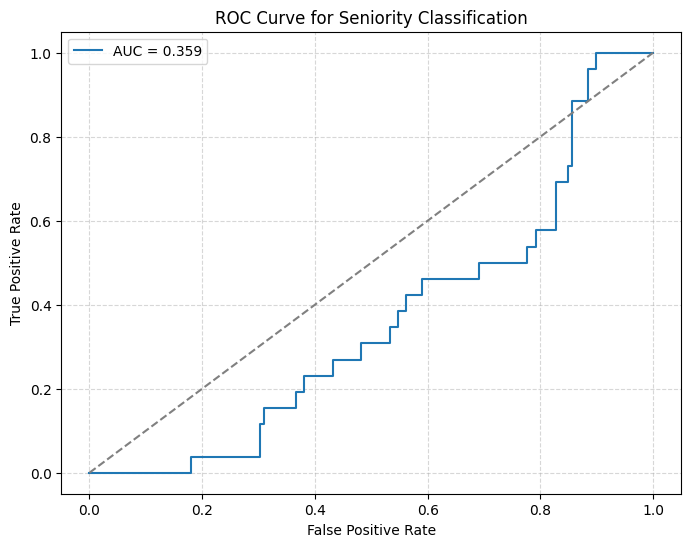

In [5]:
 #Visualization Section

# Histogram of company ratings
plt.figure(figsize=(10, 6))
plt.hist(df["Rating"], bins=20, edgecolor="black", color="#083F98")

plt.title("Distribution of Company Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()


salary_by_state = df.groupby("job_state")["avg_salary"].mean().sort_values()

plt.figure(figsize=(12, 6))
salary_by_state.plot(kind="bar", color="#4C72B0", edgecolor="black")

plt.title("Average Salary by Job State")
plt.xlabel("Job State")
plt.ylabel("Average Salary")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()


plt.figure(figsize=(12, 6))
plt.plot(df["company_age"], df["avg_salary"], marker="o", linewidth=2)

plt.title("Average Salary by Company Age", fontsize=16)
plt.xlabel("Company Age (years)", fontsize=14)
plt.ylabel("Average Salary", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()


plt.figure(figsize=(10,6))
plt.scatter(kmeans_setup["max_salary"], X["company_age"], c=kmeans_setup["cluster"], cmap="viridis", alpha=0.6)
plt.scatter(centroids[:,0], centroids[:,1], c="red", s=200, marker="X")
plt.xlabel("Max Salary")
plt.ylabel("Company Age")
plt.title("K-Means Clustering of Max Salary vs Company Age")
plt.grid(True, linestyle="--", alpha=0.5)


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Seniority Classification")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)




plt.show()